In [ ]:
import pykasso as pk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go
import networkx as nx
import importlib
import seaborn as sns
import os
import sys
import gempy as gp
import gempy_viewer as gpv
# import contextily as cx
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages
# import cfpy

ModuleNotFoundError: No module named 'contextily'

In [38]:
import utils.common
import utils.conduits
import utils.geos
importlib.reload(utils.common)
importlib.reload(utils.geos)
importlib.reload(utils.conduits)
from utils.common import *
from utils.geos import * 
from utils.conduits import *



In [34]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

# Generate Single Straight Line Conduit

In [20]:
nodes = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/nodes.csv')
edges = pd.read_csv('../../data/networks/single_conduit/straight_conduit_n62/edges.csv')

In [21]:
plot_3D_network(nodes, edges, node_color='type')

In [24]:
edges['length'] = np.sqrt((edges.x_0 - edges.x_1)**2 + (edges.y_0 - edges.y_1)**2 + (edges.z_0 - edges.z_1)**2)

# Generate Straight Line Multi-conduit Network

In [51]:
new_nodes = pd.read_csv('../../data/networks/multiconduit/straight_n5/nodes.csv', index_col=False)
new_edges = pd.read_csv('../../data/networks/multiconduit/straight_n5/edges.csv', index_col=False)
new_edges = extract_edge_coordinates(new_nodes, new_edges)
new_nodes, new_edges = densify_edges(new_nodes, new_edges, density_factor=20)
new_nodes, new_edges = reset_node_ids(new_nodes, new_edges)

In [37]:
new_edges['length'] =  np.sqrt((new_edges.x_0 - new_edges.x_1)**2 + (new_edges.y_0 - new_edges.y_1)**2 + (new_edges.z_0 - new_edges.z_1)**2)

In [55]:
new_nodes.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/nodes.csv', index = False)
new_edges.to_csv('../steady_state/conduit_geometry_test/networks/branching_straight_network/edges.csv', index = False)

In [53]:
plot_3D_network(new_nodes, new_edges, node_color='type')

# Generate Geologic Model

In [5]:
# Define the path to the dataset hosted online
data_path = 'https://raw.githubusercontent.com/cgre-aachen/gempy_data/master/'

# Create a GeoModel instance with the given project name, extent, and refinement level.
data = gp.create_geomodel(
    project_name='horizontal',
    extent=[0, 1000, 0, 1000, 0, 1000],
    refinement=6,
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=data_path + "/data/input_data/jan_models/model1_orientations.csv",
        path_to_surface_points=data_path + "/data/input_data/jan_models/model1_surface_points.csv"
    )
)

# Map a geological series to the corresponding surfaces.
# Here, the "Strat_Series" is associated with two formations ('rock2' and 'rock1'),
# which defines the stacking order of horizontal layers.
gp.map_stack_to_surfaces(
    gempy_model=data,
    mapping_object={"Strat_Series": ('rock2', 'rock1')}
)

# Compute the geological model using the provided data and mappings.
gp.compute_model(data)
geo_data = data

Surface points hash:  6f1a39ed77e87a4057f03629c946b1876b87e24409cadfe0e1cf7ab1488f69e4
Orientations hash:  04c307ae23f70252fe54144a2fb95ca7d96584a2d497ea539ed32dfd23e7cd5d
Setting Backend To: AvailableBackends.numpy


c:\Users\huan1428\.conda\envs\pyKasso\Lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


In [7]:
geo_data

{'geophysics_input': None,
 'grid': Grid(values=array([[  7.8125,   7.8125,   7.8125],
       [  7.8125,   7.8125,  23.4375],
       [  7.8125,   7.8125,  39.0625],
       ...,
       [992.1875, 992.1875, 960.9375],
       [992.1875, 992.1875, 976.5625],
       [992.1875, 992.1875, 992.1875]], shape=(262144, 3)),
              length=array([], dtype=float64),
              _octree_grid=RegularGrid(resolution=array([64, 64, 64]),
                                       extent=array([   0., 1000.,    0., 1000.,    0., 1000.]),
                                       values=array([[  7.8125,   7.8125,   7.8125],
       [  7.8125,   7.8125,  23.4375],
       [  7.8125,   7.8125,  39.0625],
       ...,
       [992.1875, 992.1875, 960.9375],
       [992.1875, 992.1875, 976.5625],
       [992.1875, 992.1875, 992.1875]], shape=(262144, 3)),
                                       mask_topo=array([], shape=(0, 3), dtype=bool),
                                       _transform=None),
              

# Generate Network with PyKasso

In [59]:
import bear_spring_pykasso_settings
importlib.reload(bear_spring_pykasso_settings)
from bear_spring_pykasso_settings import *

In [60]:
app = pk.pykasso()
# Create a new project and declare its parameters
app.new_project(name=name, grid_parameters=grid_parameters)
app.visualizer.notebook = True
nx, ny, nz = app.project.grid.shape

In [ ]:
geo = app.model.geology.get_data_model()
cost = np.random.rand(588,475,2)

AttributeError: 'Geology' object has no attribute 'get_cost_model'

In [51]:
settings = 'dye_trace'

In [51]:
DEM_path = '../../data/DEM/dem_1m_m.bil'
crs = 'EPSG:32615'
grid = read_DEM_data(DEM_path, x0, x1, y0, y1, dx, dy, crs)

In [52]:
azimuth = 350
dip = 0 #np.pi/180/5
slope = np.tan(dip)
azimuth_rad = np.radians(azimuth)
dz_dx = slope * np.cos(azimuth_rad)  # Change in Z per unit X
dz_dy = slope * np.sin(azimuth_rad)  # Change in Z per unit Y
x, y = np.meshgrid(np.arange(nx), np.arange(ny))
grid = z1 - ((nx - x-1)* dx * dz_dx) + ((ny - y-1) * dy * dz_dy)

In [22]:
bedrock = grid - 10#assume bedrock is right below surface

In [61]:
# top = np.load('../../data/DEM/dem_grid_bear_spring.npy')
model_parameters[settings]['domain']['topography'] = grid.T
# model_parameters[settings]['domain']['bedrock'] = bedrock.T

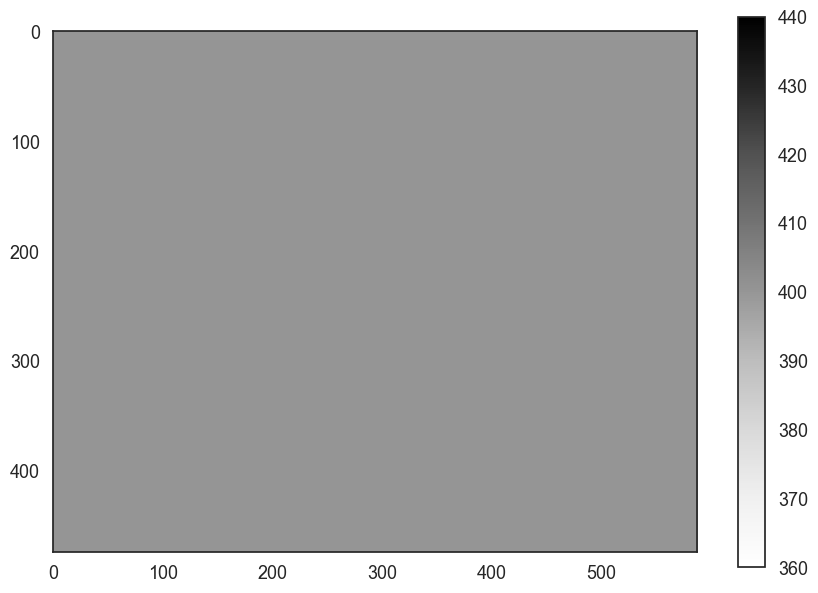

In [24]:
plt.imshow(grid)
plt.colorbar()

In [62]:
for i in range(1):
    app.model.generate(model_parameters[settings])
    # print(app.model.model_parameters['sks']['seed'])


In [63]:
edges = pd.DataFrame.from_dict(app.model.vectors['edges'], orient = 'index')
nodes = pd.DataFrame.from_dict(app.model.vectors['nodes'], orient ='index')
nodes.columns = ['x', 'y', 'z', 'type']
nodes = nodes.reset_index().rename({'index':'id'}, axis=1)
nodes['z'] = 395 # set all nodes to the same elevation to create a 2D network
edges.columns = ['from_id', 'to_id']
edges = extract_edge_coordinates(nodes, edges)
nodes, edges = reduce_edge_density(nodes, edges, .5)

C:\Users\huan1428\AppData\Local\Temp\ipykernel_12188\28240930.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



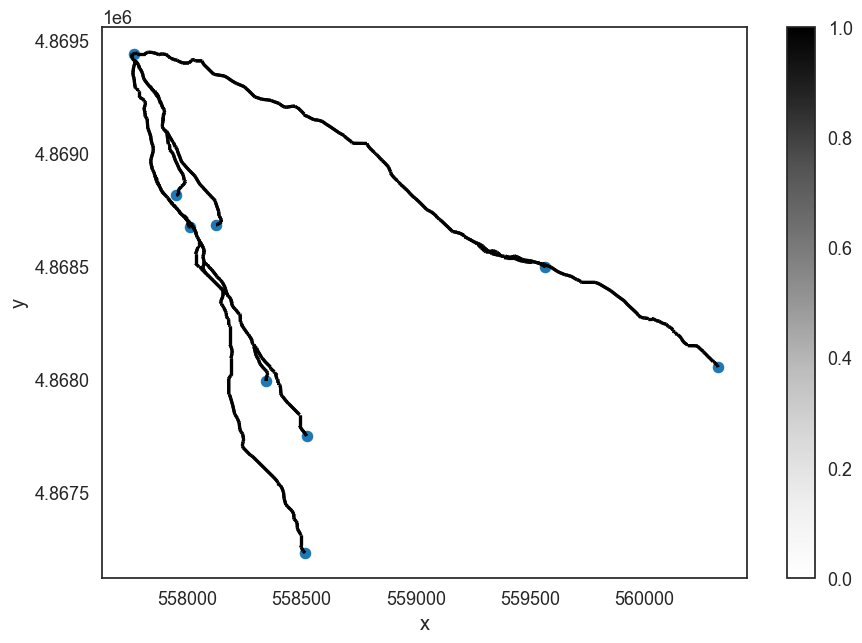

In [ ]:
ax = plot_2D_network(nodes, edges, grid = False)
sns.scatterplot(nodes[(nodes.type == 'outlet') | (nodes.type == 'inlet')], x = 'x', y = 'y', palette = 'viridis')
ax.patch.set_alpha(0.0)   # Makes the inner plot area transparent
source = cx.providers.Esri.WorldImagery

# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs=config.crs, 
    source=source, 
    zoom="auto"
)
plt.savefig('test_fig', transparent = True)

In [27]:
plot_3D_network(nodes, edges, node_color='type')

In [15]:
coords = get_cell_id_from_coords(nodes[nodes.type == 'inlet'].x, nodes[nodes.type=='inlet'].y, x0, y1, dy, dx)

In [153]:
coords = app.project.grid.get_indices(nodes[nodes.type == 'inlet'][['x', 'y']])

<Axes: xlabel='x', ylabel='y'>

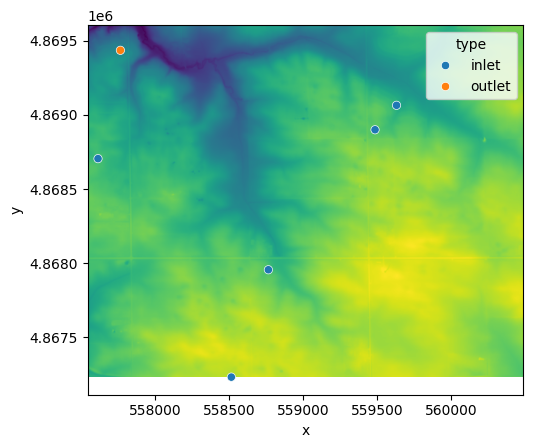

In [150]:
plt.imshow(grid, extent = (x0, x1, y0, y1))
sns.scatterplot(nodes[(nodes.type =='inlet') |(nodes.type =='outlet') ], x = 'x', y = 'y', hue = 'type')

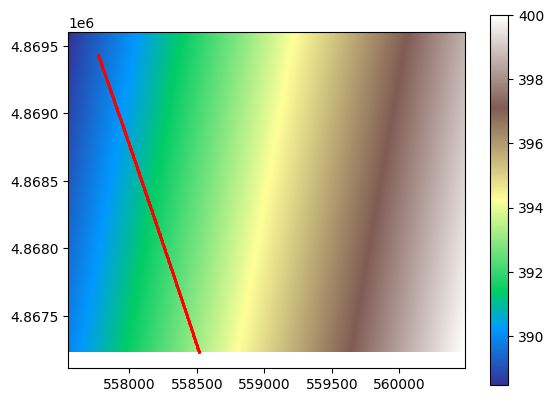

In [113]:
plt.imshow(grid, extent=(x0, x1, y0, y1), origin='upper', cmap='terrain')
plt.colorbar()
plt.scatter(nodes['x'], nodes['y'], c='r', s=1)

In [186]:
plot_3D_network(nodes, edges, node_color='type')

## Changing Slope

In [191]:
dz = 2
nodes = pd.read_csv("../steady_state/conduit_geometry_test/networks/sinkhole_spring/nodes.csv")
nodes.loc[nodes.type == 'inlet', 'z'] = dz
nodes.loc[nodes.type=='outlet', 'z'] = 0

In [192]:
edges = pd.DataFrame({'from_id' : [0], 'to_id' : [1]})
nodes, edges = reset_node_ids(nodes, edges)
nodes, edges = densify_edges(nodes, edges, 70)
edges = conduit_lengths(nodes, edges)
edges['dz_dl'] = (edges.z_1 - edges.z_0)/edges.length
plot_3D_network(nodes, edges, node_color = 'type', edge_color = 'dz_dl')

In [195]:
nodes.to_csv("../steady_state/conduit_geometry_test/networks/slope_0008/nodes.csv", index = False)
edges.to_csv("../steady_state/conduit_geometry_test/networks/slope_0008/edges.csv", index = False )

# Closed loop